# Exercise 2 — Flood impact for one storm of an ensemble

An ensemble of 198 simulated storms, each with its own flood depth map. This
notebook takes one storm out of that ensemble and works out what its flood
actually touches: how deep the water gets on each individual building and road,
and how many people, how much floor area and how many kilometres of road that
adds up to.

The question being answered is:

> **In storm 150, how deep is the water on each building and road?**

Depth is a physical quantity, so the answer needs no reference to a threshold —
worth contrasting with Exercise 3, which works from *probabilities* and
therefore does need one.

**What to take away from it**

- how to read one slice out of a large Zarr store without pulling the whole array
- how to sample a raster onto thousands of polygons in a single pass, and why the
  *maximum* over a footprint is the defensible choice here
- where each number in an impact table comes from, and which decisions along the
  way change it

**Workflow**

1. Open the storm ensemble and look at one storm
2. Load the buildings and roads
3. Sample the deepest water on each building's own footprint
4. Group into depth bands and build the impact table
5. See how impact grows across the ensemble

Everything is read from a public S3 bucket. Nothing is stored locally.

In [1]:
!pip install zarr

In [2]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
STORE = f"{BUCKET}/haiti_ibf/fim_store_Haiti_LaQuinte_v1.zarr/"                              # the storm ensemble
FEATURES = f"{BUCKET}/Haiti+training/outputs/impact_features.gpkg"     # buildings + roads

print("ready")

ready


## 1. The storm ensemble

The flood maps live in a **Zarr store** — think of it as an array split into many
small files, so you can read one slice without downloading the whole thing. The
`depth` array here is about 108 MB in total; we only ever want one storm at a
time.

The store carries its own metadata. Read that first: it tells you where you are,
what units you are in, and — importantly — what *not* to trust.

In [3]:
import zarr
from zarr.storage import FsspecStore

group = zarr.open_group(FsspecStore.from_url(STORE), mode="r")
attrs = dict(group.attrs)

for key, value in attrs.items():
    print(f"{key:22} {value}")

crs                    EPSG:32618
transform              [2.0, 0.0, 740413.47, 0.0, -2.0, 2156979.145]
extent_threshold_m     0.05
source_nodata          None
n_storms               200
grid_shape             [3557, 3417]
depth_scale            0.01
depth_units            centimeters
magnitude_source       real RainyDay storm totals: area weighted mean of the band summed scenario rain geotiff over the hydrodynamic model footprint (200 scenarios, 72 bands, 0.027 degree grid)
depth_source           LaQuinte.zip delivery, MaximumDepth.tif of each sample's MaxVeloc-dept.zip (float32 metres, 2 m grid), stored as uint16 centimetres
scenario_names         {'sample_0007': 'LaQuinta_Haiti_WRF_Box_rlz1year4121storm4', 'sample_0002': 'LaQuinta_Haiti_WRF_Box_rlz1year2614storm4', 'sample_0004': 'LaQuinta_Haiti_WRF_Box_rlz1year3196storm3', 'sample_0019': 'LaQuinta_Haiti_WRF_Box_rlz1year6564storm4', 'sample_0006': 'LaQuinta_Haiti_WRF_Box_rlz1year4110storm3', 'sample_0016': 'LaQuinta_Haiti_WRF_Box_rlz

Three things to take from that:

- **`site` / `country`** — Santa Inés Petapa, Guatemala.
- **`extent_threshold_m: 0.05`** — the model does not consider a cell wet below
  5 cm. We will reuse that number rather than inventing our own.
- **`note`** — *"magnitudes are placeholders"*. The storms were sorted by flooded
  area and rainfall magnitudes assigned to the ranks. So a storm's "mm" figure is
  a label, **not measured rainfall**. Plotting impact against it would look like a
  finding and would actually be circular. We will plot against storm *index*
  instead.

`depth` is in **metres**, and `transform` + `crs` tell us where each cell sits.

In [4]:
depth = group["depth"]
print(f"depth array: shape {depth.shape}  dtype {depth.dtype}  chunks {depth.chunks}")
print(f"  -> {depth.nbytes / 1e6:.0f} MB in total, "
      f"{np.prod(depth.chunks) * 4 / 1e3:.0f} KB per storm")

STORM = 150                      # try changing this: 2 is nearly dry, 199 is the worst
one_storm = np.asarray(depth[STORM], dtype="float32")
one_storm = np.where(np.isfinite(one_storm) & (one_storm > 0), one_storm, 0.0)

wet = one_storm[one_storm >= attrs["extent_threshold_m"]]
print(f"\nstorm {STORM}: {wet.size:,} wet cells, "
      f"max {one_storm.max():.2f} m, mean where wet {wet.mean():.2f} m")

depth array: shape (200, 3557, 3417)  dtype uint16  chunks (1, 3557, 3417)
  -> 4862 MB in total, 48617 KB per storm

storm 150: 6,638,625 wet cells, max 814.00 m, mean where wet 42.90 m


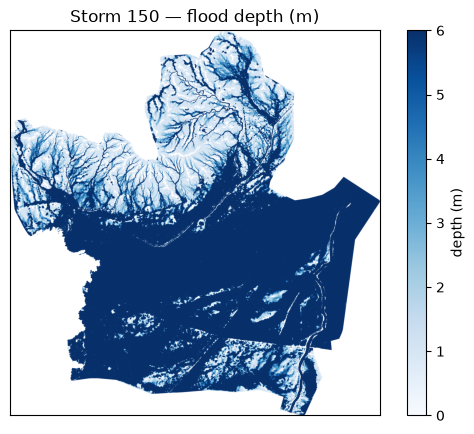

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
shown = np.where(one_storm >= attrs["extent_threshold_m"], one_storm, np.nan)
im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=6)
ax.set_title(f"Storm {STORM} — flood depth (m)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label="depth (m)")
plt.show()

## 2. The ensemble summary

Per-storm statistics are cheap for *one* storm but expensive for all 200 — that
means reading the whole 108 MB array. So the summary is **precomputed** once and
published next to the store as a small CSV, and anything needing a per-storm
figure reads that instead of the arrays.

This is a pattern worth copying: if a figure has to be derived from a large
dataset, compute it once offline rather than on every request.

In [ ]:
import tempfile
import urllib.request
from pathlib import Path

import pyogrio

def cached(url):
    """Fetch once and read the layers from the copy.

    Reading a geopackage straight off https goes through GDAL's /vsicurl, which
    range-requests a 56 MB file into the ground: minutes per layer against 12 s
    for the whole download.
    """
    path = Path(tempfile.gettempdir()) / url.rsplit("/", 1)[-1]
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return path

HAITI_LAYERS = {
    "batiment": ("Haiti_LaQuinte_cycle_20230602_bldgs", {
        "probability_30cm": "probability_severe",
        "building_area_m2": "surface_m2",
        "population_per_building": "population",
    }),
    "route": ("Haiti_LaQuinte_cycle_20230602_roads", {
        "road_length_m": "longueur_m",
    }),
}

PROB_FIELDS = ["probability_low", "probability_med", "probability_high", "probability_severe"]

source = cached(FEATURES)
parts = []
for type_, (layer, renames) in HAITI_LAYERS.items():
    # Fields already carrying their final name, plus the ones to rename.
    columns = [f for f in PROB_FIELDS if f not in renames.values()]
    part = pyogrio.read_dataframe(source, layer=layer, columns=columns + list(renames),
                                    read_geometry=False, use_arrow=True)
    part = part.rename(columns=renames)
    part["type"] = type_
    parts.append(part)
features = pd.concat(parts, ignore_index=True)

stats = pd.read_csv(f"{STORE}/ensemble_stats.csv")
print(f"{len(stats)} rows — one per storm\n")
stats.head(3)

,probability_low,probability_med,probability_high,probability_severe,surface_m2,population,type,longueur_m
0,NaN,NaN,NaN,NaN,19.6,0.13,batiment,NaN
1,NaN,NaN,NaN,NaN,11.5,0.07,batiment,NaN
2,NaN,NaN,NaN,NaN,11.8,0.08,batiment,NaN


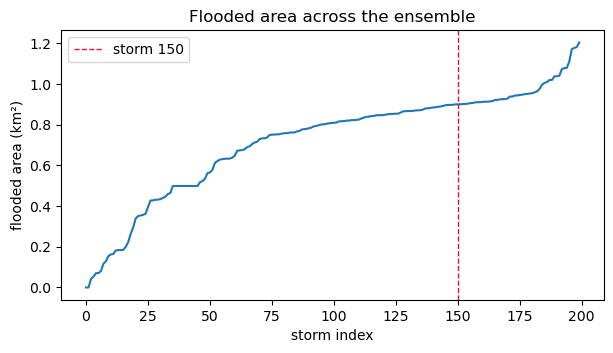

strictly non-decreasing: True


In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(stats.storm_index, stats.area_km2, lw=1.5)
ax.axvline(STORM, color="crimson", ls="--", lw=1, label=f"storm {STORM}")
ax.set_xlabel("storm index"); ax.set_ylabel("flooded area (km²)")
ax.set_title("Flooded area across the ensemble")
ax.legend(); plt.show()

increasing = bool((stats.area_km2.diff().dropna() >= 0).all())
print(f"strictly non-decreasing: {increasing}")

That curve rises monotonically because the ensemble was **sorted by flooded
area**. Stepping through the storms therefore walks *severity*.

Note also that storms 0 and 1 are completely dry: their chunks were never written,
because Zarr omits chunks that are entirely fill-value. That is why the usable
range starts at 2.

## 3. The buildings and roads

The exposure data is a slimmed-down copy of an IBF geopackage: only the features
that carry flood information, with geometry kept so we can map them.

In [8]:
features = gpd.read_file(FEATURES)
print(f"{len(features):,} features  |  CRS {features.crs}")
print(features.tipo.value_counts().to_string())
print()
features[["tipo", "poblacion", "area_m2", "longitud_m"]].head(3)

5,147 features  |  CRS EPSG:32615
tipo
edificio     4689
carretera     458



,tipo,poblacion,area_m2,longitud_m
0,edificio,6.22,178.0,0.0
1,edificio,5.08,145.4,0.0
2,edificio,4.44,127.0,0.0


`poblacion` is the **per-building** population estimate. A trap worth knowing
about: the source geopackage also has a `Población` column that repeats the whole
*municipality* total on every building. Summing that one overstates exposure by
four orders of magnitude. Always check whether a population field is a total or a
disaggregation.

## 4. Sampling depth onto each feature

We want, for each building, **the deepest water anywhere on its footprint**. That
is the conservative reading, and it matches how the IBF probabilities in Exercise 3
were sampled, so the two products stay comparable.

Doing this one feature at a time would be slow. Instead:

1. **Rasterise once** — burn each feature's *id* into a grid. This does not depend
   on the storm, so it is paid once and reused for all 200.
2. For each storm, take the maximum depth per id with `np.maximum.at`, which is a
   single pass over the cells.

The features are stored in a different CRS from the ensemble, so they are
reprojected onto the store's own grid first — cheap, because it is vector data.

`all_touched=True` means a cell counts if the feature touches it at all, not only
if the cell centre falls inside — important when buildings are only a few cells
across.

In [9]:
zarr_transform = rasterio.Affine(*attrs["transform"])
rows, cols = attrs["grid_shape"]
features = features.to_crs(attrs["crs"])

ids = rasterize(
    ((geom, i + 1) for i, geom in enumerate(features.geometry)),   # 0 means "no feature"
    out_shape=(rows, cols),
    transform=zarr_transform,
    fill=0,
    all_touched=True,
    dtype="int32",
) # create a grid of feature IDs, 0 means "no feature"

in_domain = np.unique(ids)
in_domain = in_domain[in_domain > 0]
print(f"{int((ids > 0).sum()):,} of {ids.size:,} cells are covered by a feature")
print(f"{len(in_domain):,} of {len(features):,} features land on the grid "
      f"({100 * len(in_domain) / len(features):.1f}%)")

41,808 of 135,256 cells are covered by a feature
5,029 of 5,147 features land on the grid (97.7%)


**118 features fall outside the model domain.** The domain is only 3.38 km²
and the geopackage extends beyond it, so those features can never be reported as
affected — whatever the storm. When you quote a percentage, say "of 5,029 in the
model domain", not "of 5,147", or you quietly understate the impact.

In [10]:
def feature_max_depth(storm_index):
    """Deepest water over each feature's own footprint, in metres."""
    layer = np.asarray(depth[storm_index], dtype="float32")
    # The store's nodata is a large negative float. Anything non-finite or
    # negative is "no water", not a depth.
    layer = np.where(np.isfinite(layer) & (layer > 0), layer, 0.0)

    per_feature = np.zeros(len(features) + 1, dtype="float32")
    np.maximum.at(per_feature, ids.ravel(), layer.ravel())
    return per_feature[1:]          # drop index 0: every cell with no feature

depths = feature_max_depth(STORM) # calculate the deepest water over each feature's footprint for a single storm
print(f"storm {STORM}: {int((depths >= 0.05).sum()):,} features touched by water")
print(f"  deepest single feature: {depths.max():.2f} m")

storm 150: 2,792 features touched by water
  deepest single feature: 13.16 m


## 5. Depth bands

Now group the depths into bands. These are round numbers chosen so each one reads
without a legend — roughly ankle, knee, and above head height. The 0.05 m floor is
the store's own `extent_threshold_m`, not a number we invented.

Assign in **ascending** order and let later assignments win, so each feature ends
up in the deepest band it reaches.

In [11]:
DEPTH_BANDS = [          # (class value, colour, lower bound in metres)
    (1, "green", 0.05),
    (2, "yellow", 0.30),
    (3, "red", 1.00),
    (4, "purple", 2.00),
]
BAND_LABEL = {1: "0.05 - 0.3 m", 2: "0.3 - 1 m", 3: "1 - 2 m", 4: "2 m or more"}


def classify_depth(values):
    band = np.zeros(len(values), dtype="uint8")     # 0 = dry
    for value, _colour, floor in DEPTH_BANDS:
        band[values >= floor] = value               # deepest band wins
    return band


features["depth_m"] = depths
features["band"] = classify_depth(depths)
features["level"] = features.band.map(BAND_LABEL)

features.band.value_counts().sort_index().rename(BAND_LABEL).rename_axis("band")

band
0               2355
0.05 - 0.3 m     329
0.3 - 1 m        411
1 - 2 m          618
2 m or more     1434
Name: count, dtype: int64

> ⚠️ **Classify before you round.** If you round the depths to 2 decimals first
> and *then* classify, features sitting at 0.0455 m round up to 0.05 and get
> promoted into the wet band. That is a display concern silently changing the
> answer — it moved 14 features when we hit it for real. Round only what you print.

## 6. The impact table

Deepest band first, so the worst case is read first, with a total across every
affected feature.

In [12]:
TOTAL_POPULATION = 290_868      # every building in the geopackage, for a share


def impact_row(name, group):
    buildings = group[group.tipo == "edificio"]
    return {
        "Depth": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.poblacion.sum():,.0f}",
        "Area (m²)": f"{group.area_m2.sum():,.0f}",
        "Roads (km)": f"{group.longitud_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.poblacion.sum() / TOTAL_POPULATION:.2f}%",
    }


affected = features[features.band > 0]
# Note: not `rows` -- that name already holds the grid height.
table_rows = [impact_row(BAND_LABEL[v], affected[affected.band == v])
              for v, _c, _f in reversed(DEPTH_BANDS)]
table_rows.append(impact_row("TOTAL affected", affected))

pd.DataFrame(table_rows).set_index("Depth")

,Buildings,Population,Area (m²),Roads (km),% of population
Depth,,,,,
2 m or more,"1,265","3,344","109,097",22.1,1.15%
1 - 2 m,553,"1,477","48,238",4.2,0.51%
0.3 - 1 m,365,"1,308","43,000",2.4,0.45%
0.05 - 0.3 m,295,825,"46,224",3.8,0.28%
TOTAL affected,"2,478","6,955","246,558",32.5,2.39%


## 7. Mapping it

The affected features, coloured by depth band, drawn over the depth raster.

/tmp/ipykernel_72669/2409181579.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


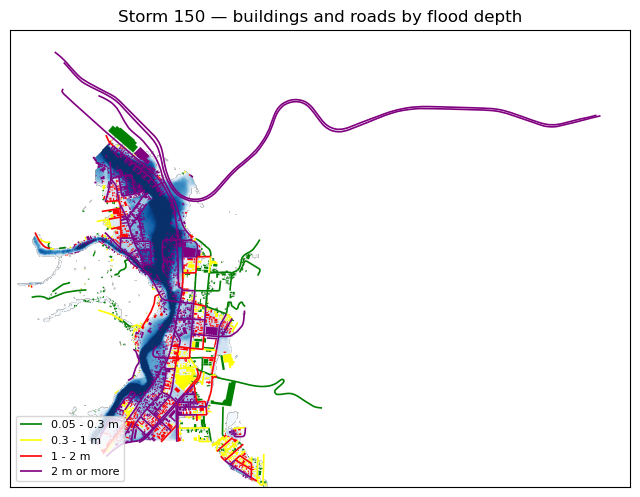

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
extent = rasterio.transform.array_bounds(rows, cols, zarr_transform)
ax.imshow(shown, cmap="Blues", vmin=0, vmax=6,
          extent=(extent[0], extent[2], extent[1], extent[3]))

for value, colour, _floor in DEPTH_BANDS:
    subset = features[features.band == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.2, label=BAND_LABEL[value])

ax.set_title(f"Storm {STORM} — buildings and roads by flood depth")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

Only features that reach a band are drawn. Dry ones are the large majority and
add nothing a basemap does not already show — dropping them also takes the
payload from about 2 MB down to a few hundred KB, which matters when it is
re-fetched every time the storm changes.

## 8. How the dashboard plugin does it

Everything above runs here, in a notebook. To put it on a dashboard the same code
has to become a **plugin**: an installable Python package that TethysDash finds on
its own and runs custom python code for the frontend.

### Discovery — how the app finds it

A plugin is a class registered as an **Intake entry point** in its package's
`pyproject.toml`:

```toml
[project.entry-points."intake.drivers"]
wmo_storm_impact_summary_en = "tgf_wmo_plugins.storm_impact_summary:StormImpactSummaryEN"
wmo_storm_impact_layer_en   = "tgf_wmo_plugins.storm_impact_layer:StormImpactLayerEN"
wmo_storm_card_en           = "tgf_wmo_plugins.storm_card:StormCardEN"
```

Once the plugin is installed with TethysDash, users can integrate it into
their own dashboards to view the results.

### The class — discovery properties, args, and one method

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class StormImpactSummaryEN(TethysDashPlugin):

    # ---- discovery: how the GUI lists and presents this plugin -----------
    name = "wmo_storm_impact_summary_en"      # must match the entry-point key
    label = "Storm Impact Summary (English)"  # the row in the dropdown
    group = "Flood Maps (English)"            # the heading it is filed under
    description = "People, buildings and roads by flood depth for one storm."
    tags = ["flood", "impact", "zarr", "storm", "table", "english"]

    # ---- what kind of visualization this is ------------------------------
    type = "table"
    # `type` picks the frontend renderer, and therefore dictates the shape
    # run() must return. One of: table, card, plotly, image, text,
    # variable_input, map, map_layer, custom.

    # ---- what the GUI asks the dashboard author to fill in ---------------
    args = {
        "index": STORM_OPTIONS,   # a list of {"value", "label"} -> a dropdown
        # "number" / "text" / "checkbox" / "date" -> the matching input widget
    }
    # The arg *names* are the contract: they are the keys a dashboard stores,
    # so renaming one silently breaks every dashboard already using it. The GUI
    # derives each field's label from the name by splitting on underscores and
    # capitalising, so `index` displays as "Index".

    def run(self):
        """Called once per request, and again whenever a bound arg changes."""

        index = self.get_arg("index", 2)
        # get_arg() reads a configured value. If the author bound this arg to a
        # variable input, the "${Storm}" reference is already resolved by now --
        # the plugin never sees the template syntax.

        gdf = banded_features(index)
        # ^ the whole notebook, sections 3 to 5: load the features, sample the
        #   deepest water on each footprint, attach a depth band.

        # A `table` returns a title and a list of row dicts. Keys become the
        # columns in order; values are preformatted strings, because how a
        # number should read is a decision the renderer cannot make.
        return {"title": f"Storm {index}", "data": [{"Depth": "...", "Buildings": "..."}]}
```

Both language variants subclass one shared base that holds `run()`; the subclasses
set only `name`, `label`, `group`, `tags` and which string table to use. Nothing
that computes a number is duplicated.

### Map layers implement two methods, not one

A `map_layer` plugin is asked two different questions at two different times, so
it answers them separately:

```python
class StormImpactLayerEN(TethysDashPlugin):
    name = "wmo_storm_impact_layer_en"
    label = "Storm Impact Layer (English)"
    group = "Flood Maps (English)"
    type = "map_layer"
    dynamic_map_layer = True     # this flag is what enables fetch_features()
    args = {"index": STORM_OPTIONS}

    def run(self):
        """CONFIGURE time. Called once, when the author adds the layer.

        Returns the layer's *scaffold*, not its data: a name, a source binding,
        style rules and a legend. This is what the layer editor's
        "Fetch plugin defaults" button calls.
        """
        builder = LayerConfigurationBuilder("Flooded buildings and roads", "GeoJSON")

        builder.set_plugin_source(self.name, self.received_args)
        # received_args, NOT self.args. self.args is the *schema*; the runtime
        # re-invocation needs the configured *values*, including any "${Storm}"
        # binding that still has to be resolved on each fetch.

        builder.set_style(...)    # rules keyed on a feature attribute (`banda`)
        builder.set_legend(...)   # what the map legend shows for this layer
        return builder.build()    # -> the layer configuration dict

    def fetch_features(self):
        """RUN time. Called on load, and again every time `${Storm}` changes.

        Returns GeoJSON. This is the only part that re-executes.
        """
        self.send_update("Reading the storm...", percentage_complete=10)
        # send_update() streams progress to the tile over a WebSocket, so a
        # recompute that takes a few seconds looks busy rather than broken.

        gdf = banded_features(self.get_arg("index", 2))
        return {"type": "FeatureCollection",
                "features": [...],                     # one per affected feature
                "crs": {"type": "name",
                        "properties": {"name": "EPSG:3857"}}}
```

### The three plugins built on this data

| plugin | `type` | `run()` returns |
|---|---|---|
| `wmo_storm_impact_summary_*` | `table` | `{"title", "data": [row dicts]}` — the table from section 6 |
| `wmo_storm_impact_layer_*` | `map_layer` | a layer scaffold; `fetch_features()` then returns the GeoJSON from section 8 |
| `wmo_storm_card_*` | `card` | `{"data": [{"color", "label", "value", "icon"}]}` — headline figures, no title |

### Why the two-method split earns its keep

`run()` fires once, when someone is configuring the dashboard. `fetch_features()`
fires on every change to a bound variable. Putting the style and legend in `run()`
means they are computed once and stored with the dashboard, so changing the storm
re-runs only the part that actually depends on the storm.

All three plugins import the same core module, which caches the expensive
storm-independent step. Rasterising 5,147 features is paid once per process;
changing the storm re-reads one ~540 KB chunk and re-runs a single pass over the
cells.

### Things to try

- Change `STORM` in section 1 and re-run. Storm 2 is nearly dry; 199 is the worst
  in the ensemble.
- Change the `DEPTH_BANDS` bounds. What happens to the table if you add a
  `4 m or more` band?
- The population figures use `TOTAL_POPULATION` (every building) as the
  denominator. Recompute the percentages against only the 5,029 features inside
  the model domain. How much does the answer move?
- Section 4 takes the **maximum** depth over each footprint. Try the mean instead
  (`np.add.at` and a count) and see how the table changes. Which is the more
  defensible number to give a decision-maker?